# Fourier transforms of stellar light curves

14 May 2026

This notebook introduces Fourier transforms in the specific setting of photometric light curves. This is meant to be an introduction only, a good reference book is https://ui.adsabs.harvard.edu/abs/2018adaf.book.....B/abstract. We will move from clean sinusoids to gapped data, spectral windows, stochastic solar-like oscillations, and transit or eclipse-like signals.

By the end, students should be able to:

- connect time baseline, cadence, frequency resolution, and Nyquist frequency;
- identify aliasing and spectral leakage in a periodogram/amplitude spectrum;
- compute and interpret a window function;
- distinguish coherent oscillations from finite-lifetime stochastic oscillations;
- recognize the Fourier signature of boxy events such as transits and eclipses.

The notebook uses frequencies in cycles per day. To convert to microhertz:

```text
1 cycle/day = 11.574074 microHz
```


## 1. Setup

The only required scientific packages are NumPy and Matplotlib. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

DAY_TO_MICROHZ = 11.574074


def make_time_grid(duration_days=30.0, cadence_min=30.0):
    """Uniform observing times in days."""
    dt = cadence_min / (24 * 60)
    return np.arange(0, duration_days, dt)


def fft_amplitude_spectrum(t, y):
    """One-sided FFT amplitude spectrum for uniformly sampled data.

    Frequencies are cycles/day. Amplitudes are in the same units as y.
    The normalization makes a pure sine wave of amplitude A peak near A
    when its frequency lies exactly on an FFT bin.
    """
    t = np.asarray(t)
    y = np.asarray(y) - np.nanmean(y)
    dt = np.median(np.diff(t))
    freq = np.fft.rfftfreq(len(t), d=dt)
    amp = 2.0 * np.abs(np.fft.rfft(y)) / len(t)
    amp[0] = amp[0] / 2.0
    return freq, amp


def fft_psd(t, y, density_units="per_cycle_per_day"):
    """One-sided power spectral density for uniformly sampled data.

    The PSD is normalized so that integral(PSD df) equals the variance of
    the mean-subtracted light curve. If density_units="per_microHz", the
    frequency axis and density are converted consistently.
    """
    t = np.asarray(t)
    y = np.asarray(y) - np.nanmean(y)
    dt = np.median(np.diff(t))
    freq = np.fft.rfftfreq(len(t), d=dt)
    fourier = np.fft.rfft(y)
    psd = (dt / len(t)) * np.abs(fourier)**2
    if len(psd) > 2:
        psd[1:-1] *= 2
    if density_units == "per_microHz":
        return freq * DAY_TO_MICROHZ, psd / DAY_TO_MICROHZ
    return freq, psd


def direct_amplitude_spectrum(t, y, freq, chunk=512):
    """Direct DFT amplitude spectrum for arbitrary observing times.

    This is slower than an FFT but works naturally for gapped or irregular
    samples.
    """
    t = np.asarray(t)
    y = np.asarray(y) - np.nanmean(y)
    freq = np.asarray(freq)
    amp = np.empty_like(freq, dtype=float)
    for start in range(0, len(freq), chunk):
        f = freq[start:start + chunk]
        phase = np.exp(-2j * np.pi * f[:, None] * t[None, :])
        amp[start:start + chunk] = 2.0 * np.abs(phase @ y) / len(t)
    return amp


def window_function(t, freq, chunk=512):
    """Spectral window |sum exp(-2*pi*i*f*t)| normalized to one at f=0."""
    t = np.asarray(t)
    freq = np.asarray(freq)
    win = np.empty_like(freq, dtype=float)
    for start in range(0, len(freq), chunk):
        f = freq[start:start + chunk]
        phase = np.exp(-2j * np.pi * f[:, None] * t[None, :])
        win[start:start + chunk] = np.abs(phase.sum(axis=1)) / len(t)
    return win


def plot_lightcurve_and_spectrum(t, y, freq, amp, title="", xlim=None):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(t, y, ".", ms=2, alpha=0.8)
    ax[0].set_xlabel("Time [days]")
    ax[0].set_ylabel("Relative flux [ppm]")
    ax[0].set_title("Light curve")
    ax[1].plot(freq, amp, lw=1.2)
    ax[1].set_xlabel("Frequency [cycles/day]")
    ax[1].set_ylabel("Amplitude [ppm]")
    ax[1].set_title("Amplitude spectrum")
    if xlim is not None:
        ax[1].set_xlim(*xlim)
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    return fig, ax


def nearest_peak(freq, amp, fmin=0):
    mask = freq >= fmin
    i = np.argmax(amp[mask])
    return freq[mask][i], amp[mask][i]


## 2. A clean sinusoid: what does the FFT measure?

A light curve with one coherent pulsation is the easiest place to start. For uniformly sampled data, the FFT evaluates the discrete Fourier transform on a natural frequency grid:

```text
frequency spacing = 1 / total observing time
Nyquist frequency = 1 / (2 * cadence)
```

The frequency spacing is not the same thing as the precision of a fitted frequency, but it is the natural separation between independent Fourier bins.


Number of samples: 1440
Cadence: 0.02083 d = 30.0 min
Baseline: 29.98 d
Frequency spacing ~ 1/T: 0.0334 cycles/day
Nyquist frequency: 24.00 cycles/day
Input frequency: 12.350 cycles/day = 142.9 microHz
Highest FFT peak: 12.333 cycles/day


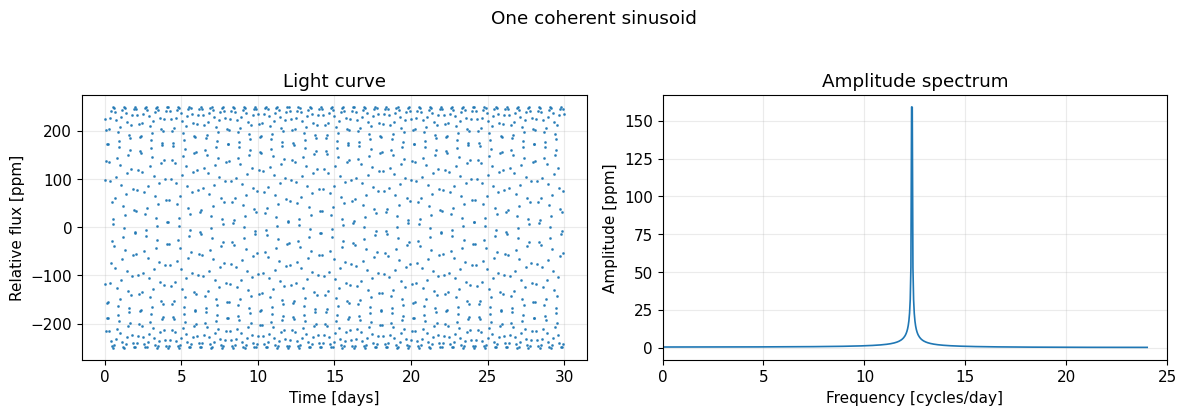

In [2]:
duration = 30.0
cadence_min = 30.0
t = make_time_grid(duration, cadence_min)
dt = np.median(np.diff(t))

f0 = 12.35          # cycles/day
amp0 = 250.0       # ppm
phase0 = 0.4
y = amp0 * np.sin(2 * np.pi * f0 * t + phase0)

freq, amp = fft_amplitude_spectrum(t, y)

print(f"Number of samples: {len(t)}")
print(f"Cadence: {dt:.5f} d = {dt*24*60:.1f} min")
print(f"Baseline: {t[-1] - t[0]:.2f} d")
print(f"Frequency spacing ~ 1/T: {1/(t[-1]-t[0]):.4f} cycles/day")
print(f"Nyquist frequency: {1/(2*dt):.2f} cycles/day")
print(f"Input frequency: {f0:.3f} cycles/day = {f0*DAY_TO_MICROHZ:.1f} microHz")
print(f"Highest FFT peak: {nearest_peak(freq, amp, fmin=0.1)[0]:.3f} cycles/day")
plot_lightcurve_and_spectrum(t, y, freq, amp, title="One coherent sinusoid", xlim=(0, 25));
plt.show()

### Units and normalizations: amplitude, power, PSD, and ASD

A Fourier transform turns a light curve from "flux as a function of time" into "how much variability is present at each frequency." The units depend on the normalization.

Common choices are:

- **Amplitude spectrum:** units of the light curve, for example `ppm`. With the normalization used above, a pure sine wave with amplitude `A ppm` gives a peak near `A ppm` if the frequency falls exactly on a Fourier bin.
- **Power spectrum:** often amplitude squared, with units such as `ppm^2`. This is power per Fourier bin, not per unit frequency.
- **Power spectral density (PSD):** power per unit frequency, for example `ppm^2 / cycle/day` or `ppm^2 / microHz`. With a variance-preserving normalization, summing/integrating the PSD over frequency recovers the time-domain variance.
- **Amplitude spectral density (ASD):** square root of PSD, for example `ppm / sqrt(microHz)`.

The distinction between `ppm^2` and `ppm^2 / microHz` matters. If you change the observing duration, Fourier bins get narrower. A PSD accounts for that bin width; a simple power spectrum does not.


Variance in time domain:       19501.9 ppm^2
Integral of one-sided PSD:     19501.9 ppm^2
Frequency bin width:           0.386 microHz


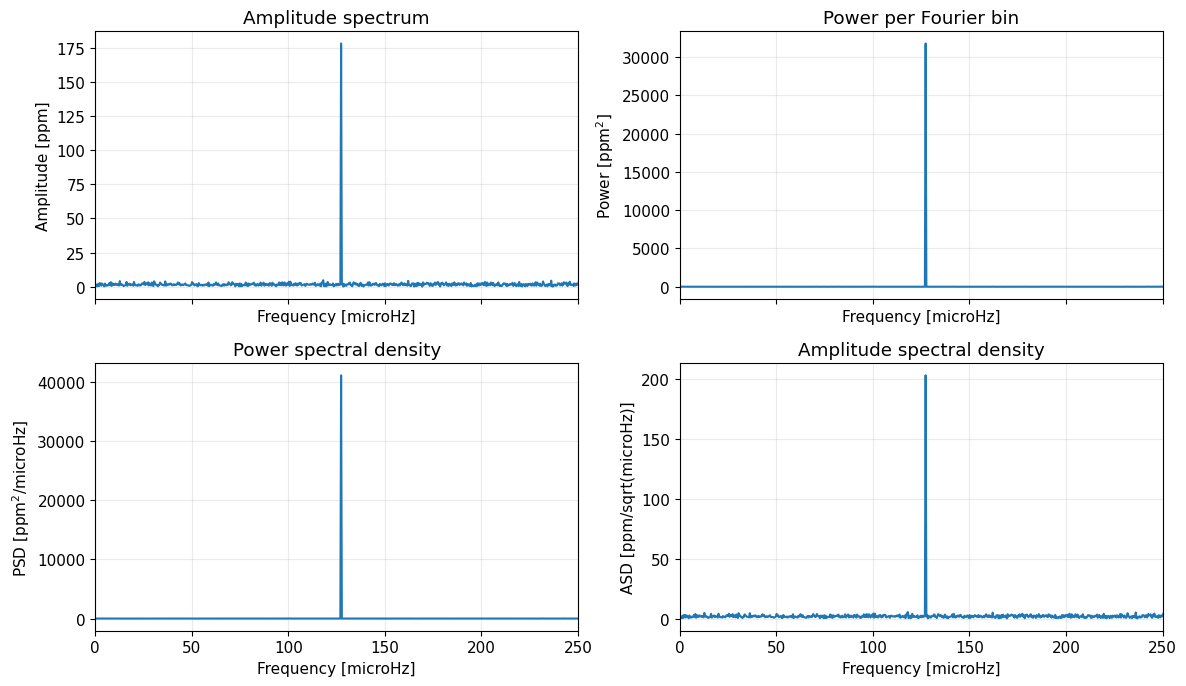

In [3]:
# Demonstrate variance preservation for a PSD.
rng = np.random.default_rng(123)
t = make_time_grid(duration_days=30, cadence_min=10)
dt = np.median(np.diff(t))

y = (
    180 * np.sin(2*np.pi*11.0*t + 0.4)
    + rng.normal(0, 60, len(t))
)
y = y - np.mean(y)

freq, amp = fft_amplitude_spectrum(t, y)
power = amp**2
freq_muHz, psd_muHz = fft_psd(t, y, density_units="per_microHz")
asd_muHz = np.sqrt(psd_muHz)

df_muHz = np.median(np.diff(freq_muHz))
variance_time = np.var(y)
variance_from_psd = np.sum(psd_muHz) * df_muHz

print(f"Variance in time domain:       {variance_time:.1f} ppm^2")
print(f"Integral of one-sided PSD:     {variance_from_psd:.1f} ppm^2")
print(f"Frequency bin width:           {df_muHz:.3f} microHz")

fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
ax[0, 0].plot(freq * DAY_TO_MICROHZ, amp)
ax[0, 0].set_ylabel("Amplitude [ppm]")
ax[0, 0].set_title("Amplitude spectrum")

ax[0, 1].plot(freq * DAY_TO_MICROHZ, power)
ax[0, 1].set_ylabel("Power [ppm$^2$]")
ax[0, 1].set_title("Power per Fourier bin")

ax[1, 0].plot(freq_muHz, psd_muHz)
ax[1, 0].set_ylabel("PSD [ppm$^2$/microHz]")
ax[1, 0].set_title("Power spectral density")

ax[1, 1].plot(freq_muHz, asd_muHz)
ax[1, 1].set_ylabel("ASD [ppm/sqrt(microHz)]")
ax[1, 1].set_title("Amplitude spectral density")

for axis in ax.flat:
    axis.set_xlim(0, 250)
    axis.set_xlabel("Frequency [microHz]")
fig.tight_layout();

### Try this

Change `duration`, `cadence_min`, and `f0`. What changes in the time series? What changes in the spectrum? What does not change?


## 3. Frequency resolution: resolving two nearby modes

A common rule of thumb is that two coherent frequencies need to be separated by roughly `1 / T` to be cleanly resolved in a plain Fourier amplitude spectrum. The exact appearance also depends on signal-to-noise ratio and relative phases.


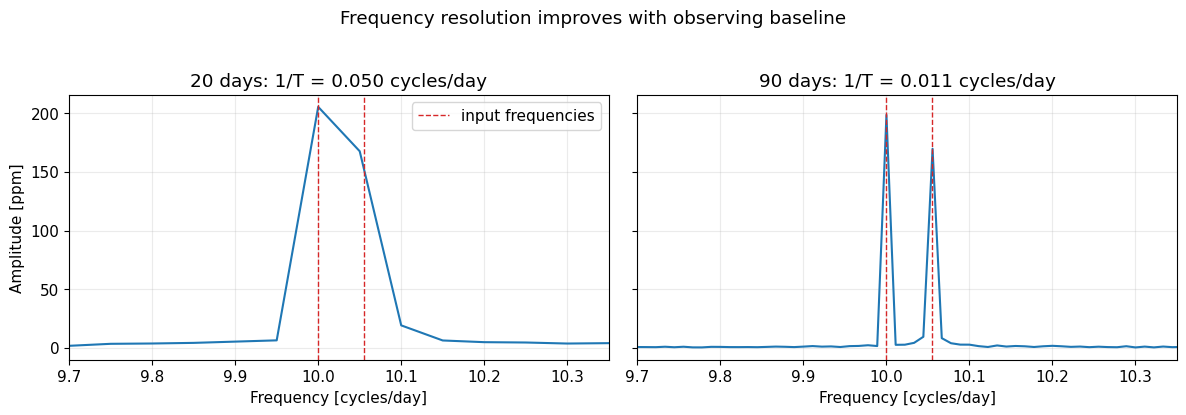

In [4]:
def two_sines(t, f1, f2, a1=200, a2=170, noise=20, seed=1):
    rng = np.random.default_rng(seed)
    return (
        a1 * np.sin(2*np.pi*f1*t + 0.2)
        + a2 * np.sin(2*np.pi*f2*t + 1.1)
        + rng.normal(0, noise, len(t))
    )

t_short = make_time_grid(20, 30)
t_long = make_time_grid(90, 30)
f1 = 10.00
f2 = 10.055

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, tt, label in zip(ax, [t_short, t_long], ["20 days", "90 days"]):
    yy = two_sines(tt, f1, f2)
    ff, aa = fft_amplitude_spectrum(tt, yy)
    axis.plot(ff, aa)
    axis.axvline(f1, color="C3", ls="--", lw=1, label="input frequencies")
    axis.axvline(f2, color="C3", ls="--", lw=1)
    axis.set_xlim(9.7, 10.35)
    axis.set_xlabel("Frequency [cycles/day]")
    axis.set_title(f"{label}: 1/T = {1/(tt[-1]-tt[0]):.3f} cycles/day")
ax[0].set_ylabel("Amplitude [ppm]")
ax[0].legend()
fig.suptitle("Frequency resolution improves with observing baseline", y=1.03)
fig.tight_layout();

## 4. Nyquist frequency and aliases

Sampling every `dt` days means the sampling frequency is `fs = 1 / dt`. A sinusoid above the Nyquist frequency, `fs / 2`, can masquerade as a lower-frequency sinusoid. This is aliasing.

For a uniformly sampled time series, a useful alias formula is:

```text
f_alias = abs(f_true - round(f_true / fs) * fs)
```


Sampling frequency: 48.0 cycles/day
Nyquist frequency: 24.0 cycles/day
True frequency: 60.0 cycles/day
Expected alias: 12.0 cycles/day
Measured peak: 12.0 cycles/day


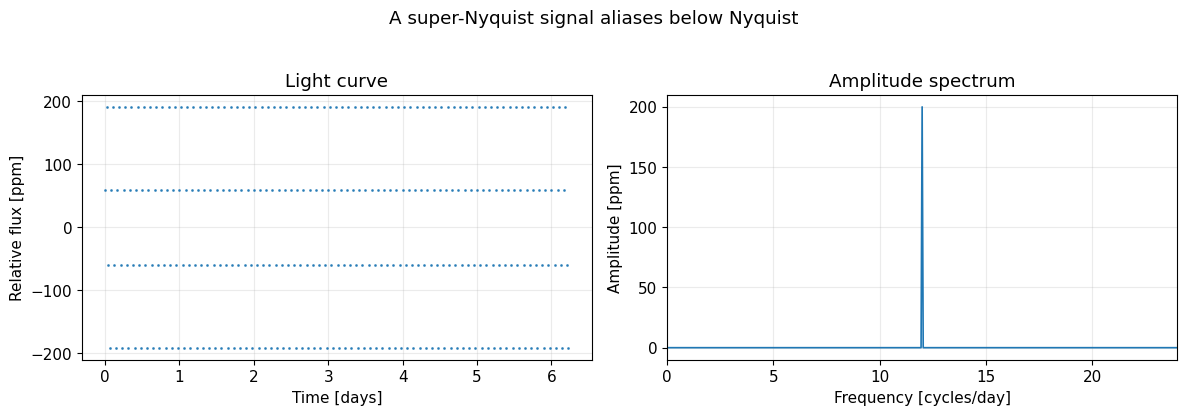

In [5]:
cadence_min = 30
t = make_time_grid(20, cadence_min)
dt = np.median(np.diff(t))
fs = 1 / dt
f_nyq = fs / 2

f_true = 60.0  # cycles/day, above the 30-minute cadence Nyquist frequency
f_alias = abs(f_true - round(f_true / fs) * fs)
y = 200 * np.sin(2*np.pi*f_true*t + 0.3)
freq, amp = fft_amplitude_spectrum(t, y)

print(f"Sampling frequency: {fs:.1f} cycles/day")
print(f"Nyquist frequency: {f_nyq:.1f} cycles/day")
print(f"True frequency: {f_true:.1f} cycles/day")
print(f"Expected alias: {f_alias:.1f} cycles/day")
print(f"Measured peak: {nearest_peak(freq, amp, fmin=0.1)[0]:.1f} cycles/day")

plot_lightcurve_and_spectrum(t[:300], y[:300], freq, amp, title="A super-Nyquist signal aliases below Nyquist", xlim=(0, f_nyq));

### Sampling a period: why "two points per cycle" is the boundary

For a signal with period `P = 1 / f`, a cadence `dt` gives:

```text
samples per period = P / dt = fs / f
```

The Nyquist condition `f < fs / 2` is equivalent to saying that the sampling provides more than two samples per period. Exactly two samples per period is a fragile limiting case: the apparent amplitude can depend strongly on phase, and there is no information about the shape between samples. In practice, more than two samples per cycle are needed for robust amplitude, phase, and waveform measurements.


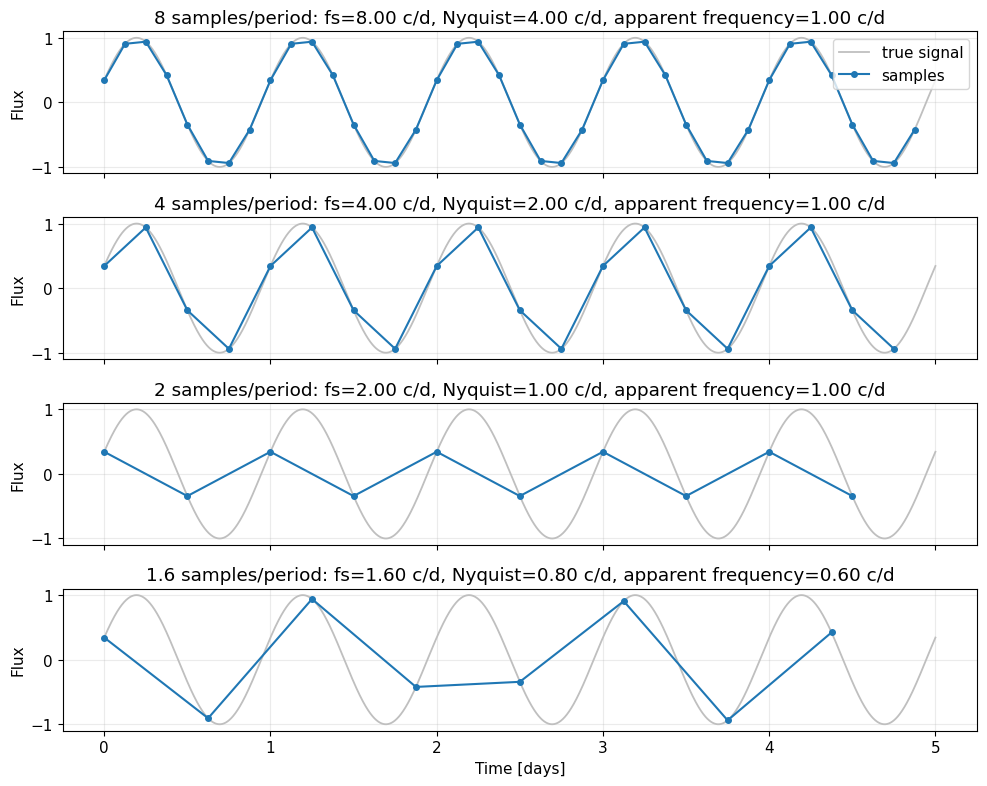

In [6]:
def alias_frequency(f_true, cadence_days):
    fs = 1 / cadence_days
    return abs(f_true - round(f_true / fs) * fs)


f_signal = 1.0  # cycles/day, so the period is 1 day
phase = 0.35
duration = 5.0
t_dense = np.linspace(0, duration, 3000)
y_dense = np.sin(2*np.pi*f_signal*t_dense + phase)
samples_per_period = [8, 4, 2, 1.6]

fig, ax = plt.subplots(len(samples_per_period), 1, figsize=(10, 8), sharex=True, sharey=True)
for axis, n_per in zip(ax, samples_per_period):
    cadence_days = 1 / (f_signal * n_per)
    t_sample = np.arange(0, duration, cadence_days)
    y_sample = np.sin(2*np.pi*f_signal*t_sample + phase)
    fs = 1 / cadence_days
    f_nyq = fs / 2
    f_alias = alias_frequency(f_signal, cadence_days)

    axis.plot(t_dense, y_dense, color="0.75", lw=1.3, label="true signal")
    axis.plot(t_sample, y_sample, "o-", color="C0", ms=4, label="samples")
    axis.set_ylabel("Flux")
    axis.set_title(
        f"{n_per:g} samples/period: fs={fs:.2f} c/d, Nyquist={f_nyq:.2f} c/d, "
        f"apparent frequency={f_alias:.2f} c/d"
    )
ax[-1].set_xlabel("Time [days]")
ax[0].legend(loc="upper right")
fig.tight_layout();

Cadence: 30 min
Sampling frequency: 48.0 cycles/day
Nyquist frequency: 24.0 cycles/day

 true frequency [c/d] -> observed alias [c/d]
      5.0              ->    5.0
     18.0              ->   18.0
     23.0              ->   23.0
     25.0              ->   23.0
     30.0              ->   18.0
     43.0              ->    5.0
     49.0              ->    1.0
     60.0              ->   12.0
     73.0              ->   23.0
     95.0              ->    1.0


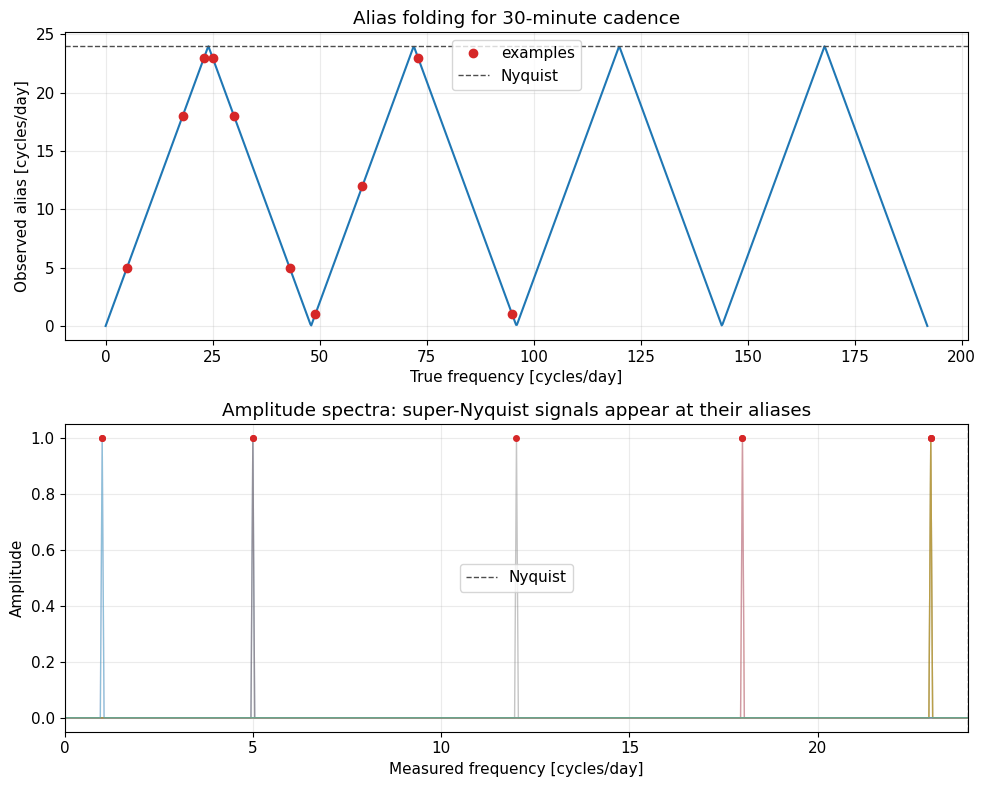

In [7]:
cadence_min = 30
cadence_days = cadence_min / (24 * 60)
fs = 1 / cadence_days
f_nyq = fs / 2

true_freqs = np.array([5, 18, 23, 25, 30, 43, 49, 60, 73, 95], dtype=float)
aliases = np.array([alias_frequency(f, cadence_days) for f in true_freqs])

print(f"Cadence: {cadence_min} min")
print(f"Sampling frequency: {fs:.1f} cycles/day")
print(f"Nyquist frequency: {f_nyq:.1f} cycles/day\n")
print(" true frequency [c/d] -> observed alias [c/d]")
for f, a in zip(true_freqs, aliases):
    print(f" {f:8.1f}              -> {a:6.1f}")

f_grid = np.linspace(0, 4*fs, 1000)
alias_grid = np.array([alias_frequency(f, cadence_days) for f in f_grid])

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(f_grid, alias_grid, color="C0")
ax[0].plot(true_freqs, aliases, "o", color="C3", label="examples")
ax[0].axhline(f_nyq, color="0.3", ls="--", lw=1, label="Nyquist")
ax[0].set_xlabel("True frequency [cycles/day]")
ax[0].set_ylabel("Observed alias [cycles/day]")
ax[0].set_title("Alias folding for 30-minute cadence")
ax[0].legend()

# Now measure the aliases from actual sampled light curves.
t = make_time_grid(20, cadence_min)
for f_true, f_alias in zip(true_freqs, aliases):
    y = np.sin(2*np.pi*f_true*t + 0.1)
    freq, amp = fft_amplitude_spectrum(t, y)
    ax[1].plot(freq, amp, alpha=0.45, lw=1)
    ax[1].plot(f_alias, amp[np.argmin(abs(freq - f_alias))], "o", color="C3", ms=4)

ax[1].axvline(f_nyq, color="0.3", ls="--", lw=1, label="Nyquist")
ax[1].set_xlim(0, f_nyq)
ax[1].set_xlabel("Measured frequency [cycles/day]")
ax[1].set_ylabel("Amplitude")
ax[1].set_title("Amplitude spectra: super-Nyquist signals appear at their aliases")
ax[1].legend()
fig.tight_layout();

In [ ]:
# These different true frequencies produce the same sampled points
# when observed at exactly the same uniform cadence.
cadence_min = 30
cadence_days = cadence_min / (24 * 60)
duration = 2.0
t_sample = np.arange(0, duration, cadence_days)
t_dense = np.linspace(0, duration, 4000)
phase = 0.2
freq_family = [12, 36, 60]  # 12 + k*48 cycles/day for 30-minute cadence

fig, ax = plt.subplots(len(freq_family), 1, figsize=(10, 7), sharex=True, sharey=True)
for axis, f in zip(ax, freq_family):
    y_dense = np.sin(2*np.pi*f*t_dense + phase)
    y_sample = np.sin(2*np.pi*f*t_sample + phase)
    axis.plot(t_dense, y_dense, color="0.75", lw=1)
    axis.plot(t_sample, y_sample, "o", color="C0", ms=4)
    axis.set_ylabel("Flux")
    axis.set_title(f"True frequency {f} c/d, observed alias {alias_frequency(f, cadence_days):.1f} c/d")
ax[-1].set_xlabel("Time [days]")
fig.suptitle("Different super-Nyquist signals can be indistinguishable after sampling", y=1.02)
fig.tight_layout();

## 5. Gaps, spectral leakage, and the window function

Real observations are not always continuous. Ground-based light curves have day-night gaps; space missions have downlinks, safe modes, scattered-light intervals, and quality cuts.

Sampling multiplies the true continuous light curve by an observing window. In Fourier space, multiplication becomes convolution: a perfect single frequency is spread out according to the spectral window.


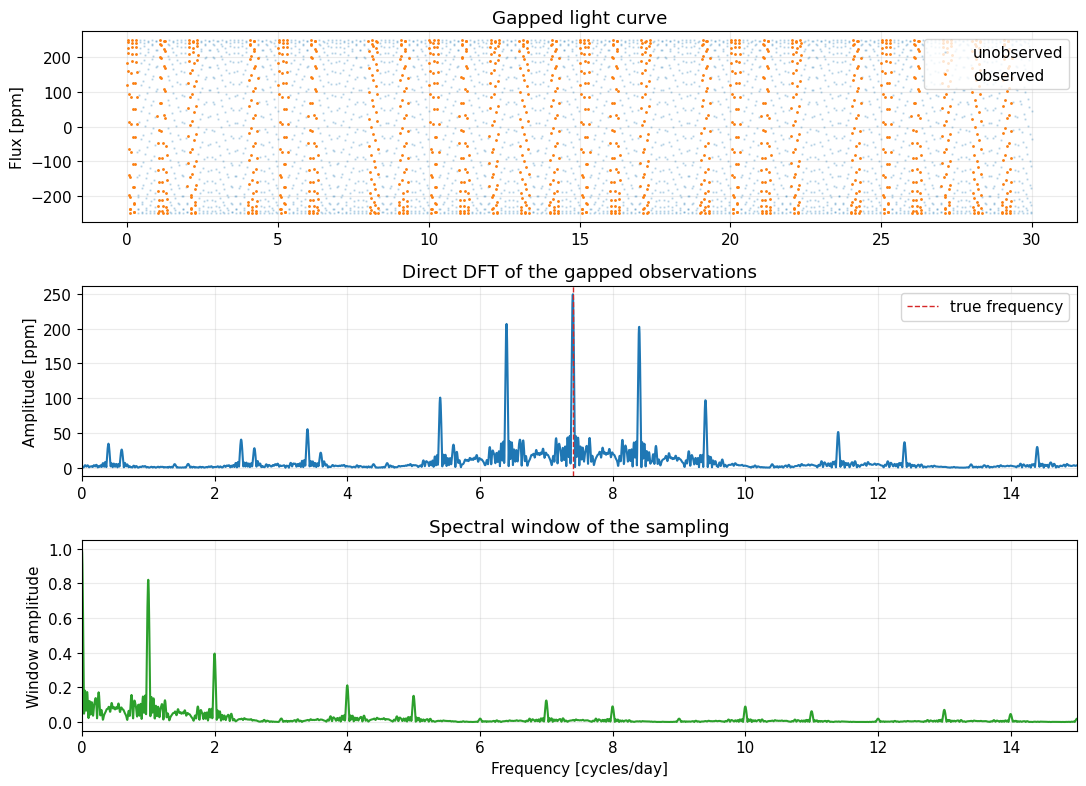

In [8]:
def ground_based_mask(t, hours_per_night=8, weather_loss=0.20, seed=4):
    rng = np.random.default_rng(seed)
    local_hour = (t % 1) * 24
    nightly = local_hour < hours_per_night
    nights = np.floor(t).astype(int)
    keep_night = rng.random(nights.max() + 1) > weather_loss
    return nightly & keep_night[nights]

t_full = make_time_grid(30, 10)
y_full = 250 * np.sin(2*np.pi*7.4*t_full + 0.5)
mask = ground_based_mask(t_full)
t_gap = t_full[mask]
y_gap = y_full[mask]

freq_grid = np.linspace(0, 20, 5000)
amp_gap = direct_amplitude_spectrum(t_gap, y_gap, freq_grid)
win = window_function(t_gap, freq_grid)

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
ax[0].plot(t_full, y_full, ".", ms=1.5, alpha=0.2, label="unobserved")
ax[0].plot(t_gap, y_gap, ".", ms=2.0, label="observed")
ax[0].set_ylabel("Flux [ppm]")
ax[0].set_title("Gapped light curve")
ax[0].legend(loc="upper right")

ax[1].plot(freq_grid, amp_gap)
ax[1].axvline(7.4, color="C3", ls="--", lw=1, label="true frequency")
ax[1].set_xlim(0, 15)
ax[1].set_ylabel("Amplitude [ppm]")
ax[1].set_title("Direct DFT of the gapped observations")
ax[1].legend()

ax[2].plot(freq_grid, win, color="C2")
ax[2].set_xlim(0, 15)
ax[2].set_xlabel("Frequency [cycles/day]")
ax[2].set_ylabel("Window amplitude")
ax[2].set_title("Spectral window of the sampling")
fig.tight_layout();

### Discussion prompts

- Why do daily aliases appear separated by about 1 cycle/day?
- Which part of the plot is caused by the star, and which part is caused by the observing schedule?
- What happens if you increase `hours_per_night` or remove `weather_loss`?


## 6. A more realistic coherent oscillator

Many classical pulsators show coherent modes with noise, slow instrumental trends, and imperfect sampling. Here the star has one dominant mode plus a weak harmonic and a low-frequency drift. The Fourier transform is powerful, but preprocessing choices matter.


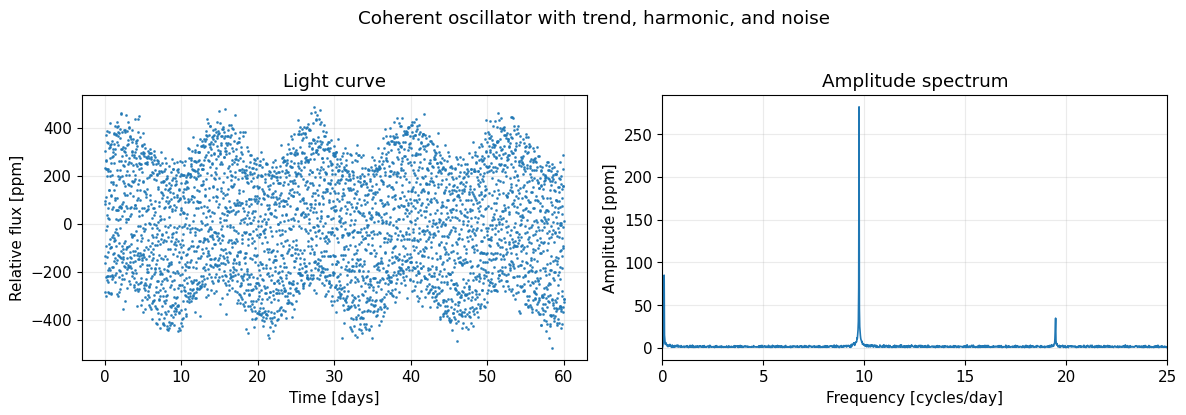

In [9]:
rng = np.random.default_rng(10)
t = make_time_grid(60, 20)
trend = 90 * np.sin(2*np.pi*0.08*t + 0.4)
mode = 300 * np.sin(2*np.pi*9.73*t + 1.2)
harmonic = 45 * np.sin(2*np.pi*2*9.73*t - 0.8)
noise = rng.normal(0, 45, len(t))
y = trend + mode + harmonic + noise

freq, amp = fft_amplitude_spectrum(t, y)

plot_lightcurve_and_spectrum(t, y, freq, amp, title="Coherent oscillator with trend, harmonic, and noise", xlim=(0, 25));

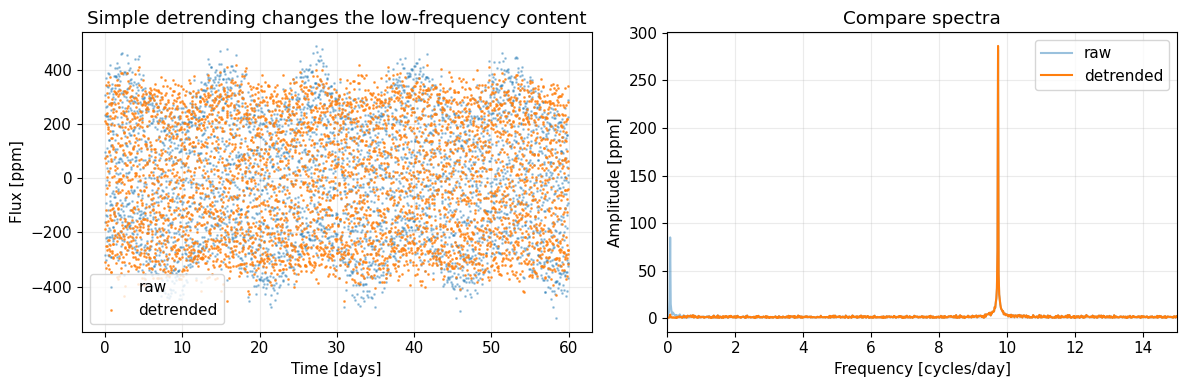

In [10]:
# A simple high-pass demonstration: subtract a running mean.
# This is intentionally simple, not a production detrending recipe.
def running_mean(y, width):
    width = int(width)
    kernel = np.ones(width) / width
    return np.convolve(y, kernel, mode="same")

cadence_days = np.median(np.diff(t))
width_days = 2.0
width_samples = round(width_days / cadence_days)
y_detrended = y - running_mean(y, width_samples)
freq_det, amp_det = fft_amplitude_spectrum(t, y_detrended)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, y, ".", ms=2, alpha=0.35, label="raw")
ax[0].plot(t, y_detrended, ".", ms=2, alpha=0.7, label="detrended")
ax[0].set_xlabel("Time [days]")
ax[0].set_ylabel("Flux [ppm]")
ax[0].legend()
ax[0].set_title("Simple detrending changes the low-frequency content")

ax[1].plot(freq, amp, alpha=0.45, label="raw")
ax[1].plot(freq_det, amp_det, label="detrended")
ax[1].set_xlim(0, 15)
ax[1].set_xlabel("Frequency [cycles/day]")
ax[1].set_ylabel("Amplitude [ppm]")
ax[1].legend()
ax[1].set_title("Compare spectra")
fig.tight_layout();

## 7. Solar-like stochastic oscillations

Solar-like oscillations are damped and randomly re-excited by convection. In a power spectrum, a single mode is often approximated by a Lorentzian profile rather than a delta function. The linewidth is related to the mode lifetime: shorter lifetimes produce broader peaks.

The simulation below builds a time series from random Fourier components whose expected power follows a Lorentzian envelope plus a red-noise granulation background.


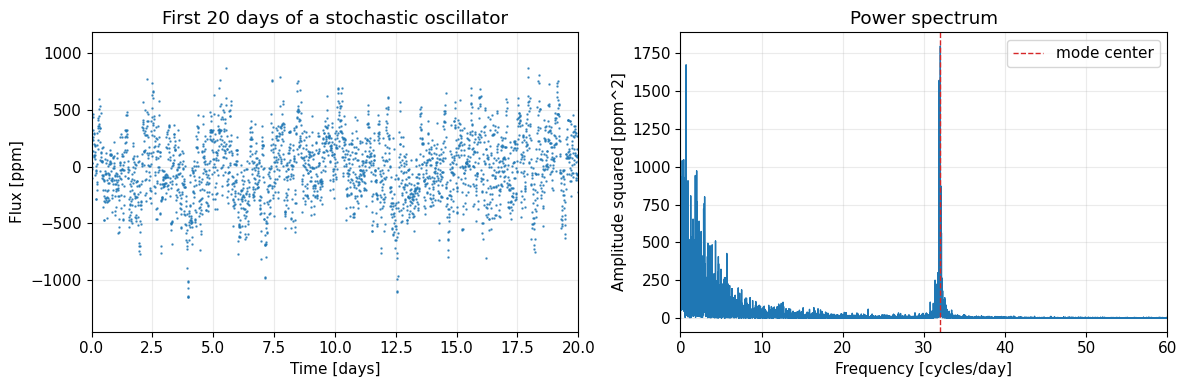

In [11]:
def colored_noise_from_psd(t, psd_shape, rms, seed=None):
    rng = np.random.default_rng(seed)
    dt = np.median(np.diff(t))
    freq = np.fft.rfftfreq(len(t), d=dt)
    shape = psd_shape(freq)
    shape = np.maximum(shape, 0)
    coeff = (rng.normal(size=len(freq)) + 1j*rng.normal(size=len(freq))) * np.sqrt(shape)
    coeff[0] = 0
    if len(coeff) > 1:
        coeff[-1] = coeff[-1].real + 0j
    y = np.fft.irfft(coeff, n=len(t))
    y = y - np.mean(y)
    if np.std(y) > 0:
        y = y / np.std(y) * rms
    return y


def lorentzian(freq, f0, linewidth):
    return 1 / (1 + 4*((freq - f0)/linewidth)**2)


t = make_time_grid(120, 10)
f_mode = 32.0       # cycles/day
linewidth = 0.35    # cycles/day

osc = colored_noise_from_psd(
    t,
    lambda f: lorentzian(f, f_mode, linewidth),
    rms=120,
    seed=21,
)
gran = colored_noise_from_psd(
    t,
    lambda f: 1 / (1 + (f/3.0)**2),
    rms=280,
    seed=22,
)
white = np.random.default_rng(23).normal(0, 35, len(t))
y = osc + gran + white

freq, amp = fft_amplitude_spectrum(t, y)
power = amp**2

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, y, ".", ms=1.5, alpha=0.75)
ax[0].set_xlim(0, 20)
ax[0].set_xlabel("Time [days]")
ax[0].set_ylabel("Flux [ppm]")
ax[0].set_title("First 20 days of a stochastic oscillator")

ax[1].plot(freq, power, lw=1)
ax[1].axvline(f_mode, color="C3", ls="--", lw=1, label="mode center")
ax[1].set_xlim(0, 60)
ax[1].set_xlabel("Frequency [cycles/day]")
ax[1].set_ylabel("Amplitude squared [ppm^2]")
ax[1].set_title("Power spectrum")
ax[1].legend()
fig.tight_layout();

In [ ]:
# Average neighboring frequency bins to make the broad mode easier to see.
def boxcar_smooth(y, width):
    kernel = np.ones(width) / width
    return np.convolve(y, kernel, mode="same")

smoothed_power = boxcar_smooth(power, 21)

plt.figure(figsize=(10, 4))
plt.plot(freq, power, color="0.75", lw=0.8, label="raw power")
plt.plot(freq, smoothed_power, color="C0", lw=1.8, label="smoothed")
plt.axvline(f_mode, color="C3", ls="--", lw=1, label="mode center")
plt.xlim(20, 45)
plt.xlabel("Frequency [cycles/day]")
plt.ylabel("Amplitude squared [ppm^2]")
plt.title("A stochastic mode is broad and noisy in one realization")
plt.legend();

### Try this

Change `linewidth`. A narrow linewidth behaves more like a coherent oscillator; a broad linewidth behaves more like a short-lived, heavily damped oscillation.


## 8. A transit or eclipse signal in Fourier space

A transit is not sinusoidal. A box-like dip repeats every orbital period, so its Fourier series contains the orbital frequency and many harmonics. Sharper ingress and egress require higher harmonics.

This matters in asteroseismology because eclipses, transits, rotational modulation, and instrumental discontinuities can inject power into frequency regions where oscillation modes also live.


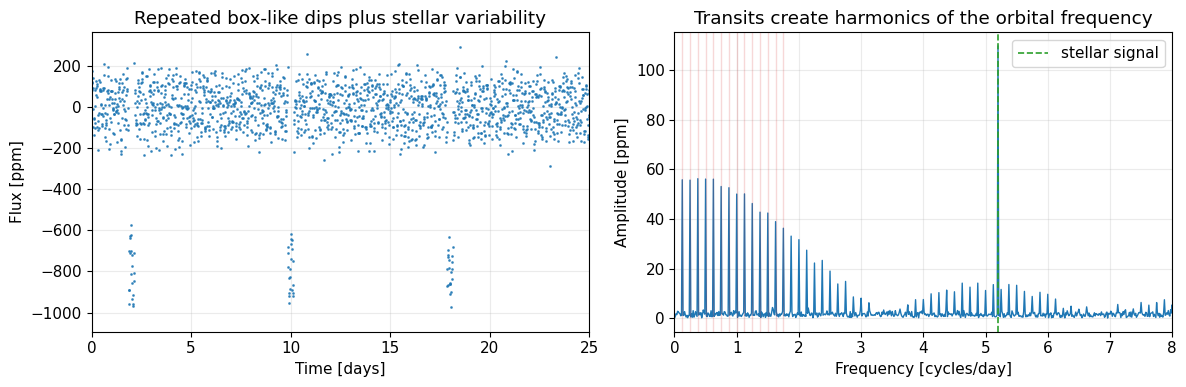

In [12]:
def box_transit(t, period=8.0, duration=0.25, depth=1000.0, t0=1.0):
    phase = ((t - t0 + 0.5*period) % period) - 0.5*period
    return -depth * (np.abs(phase) < duration/2)

t = make_time_grid(80, 20)
transit = box_transit(t, period=8.0, duration=0.28, depth=800, t0=2.0)
stellar = 110 * np.sin(2*np.pi*5.2*t + 0.3)
noise = np.random.default_rng(44).normal(0, 60, len(t))
y = transit + stellar + noise

freq, amp = fft_amplitude_spectrum(t, y)
orbital_f = 1/8.0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, y, ".", ms=2, alpha=0.75)
ax[0].set_xlim(0, 25)
ax[0].set_xlabel("Time [days]")
ax[0].set_ylabel("Flux [ppm]")
ax[0].set_title("Repeated box-like dips plus stellar variability")

ax[1].plot(freq, amp, lw=1)
for n in range(1, 15):
    ax[1].axvline(n*orbital_f, color="C3", alpha=0.18, lw=1)
ax[1].axvline(5.2, color="C2", ls="--", lw=1.2, label="stellar signal")
ax[1].set_xlim(0, 8)
ax[1].set_xlabel("Frequency [cycles/day]")
ax[1].set_ylabel("Amplitude [ppm]")
ax[1].set_title("Transits create harmonics of the orbital frequency")
ax[1].legend()
fig.tight_layout();

## 10. Key takeaways

- The Fourier frequency spacing is set by the total time baseline: longer observations separate nearby frequencies better.
- The Nyquist frequency is set by cadence: faster sampling raises the highest unambiguous frequency for uniform sampling.
- Gaps do not merely remove data; they imprint a spectral window that redistributes power into aliases and sidelobes.
- Coherent oscillators produce narrow peaks, while solar-like stochastic oscillators produce noisy, broadened peaks.
- Non-sinusoidal astrophysical signals, such as transits and eclipses, naturally produce harmonic series in Fourier space.
